In [1]:
%matplotlib inline
import os
import sys
import cv2
import torch
import matplotlib.pyplot as plt

sys.path.append('../../../')
from computer_vision.yolov11.data.utils import imread
from computer_vision.yolov11_pose.utils.viz import skeletons_overlay

In [2]:
from ultralytics import settings
from ultralytics import YOLO

output_dirpath='D:/results/yolov11_pose/predict'
settings['runs_dir']=output_dirpath
settings['weights_dir']=os.path.join(settings['runs_dir'], 'checkpoints')

In [3]:
# Load a model
model = YOLO("yolo11n-pose.pt")  # load an official model
model.kpt_shape=(17,3)
# Predict with the model
results = model("https://ultralytics.com/images/bus.jpg")  # predict on an image

# Access the results
for result in results:
    xy = result.keypoints.xy  # x and y coordinates
    xyn = result.keypoints.xyn  # normalized
    kpts = result.keypoints.data  # x, y, visibility (if available)

# torch.save({'model':model.state_dict()}, os.path.join(output_dirpath,'yolo11n_torch.pt'))


WARNING Download failure, retrying 1/3 https://ultralytics.com/images/bus.jpg... HTTP Error 403: Forbidden
image 1/1 D:\dev\computer_vision\yolov11_pose\notebook\bus.jpg: 640x480 4 persons, 192.1ms
Speed: 8.0ms preprocess, 192.1ms inference, 13.7ms postprocess per image at shape (1, 3, 640, 480)


In [28]:
model.model.model[-1]

Pose(
  (cv2): ModuleList(
    (0): Sequential(
      (0): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): Sequential(
      (0): Conv(
        (conv): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (2): Sequential(
      (0): Conv(
        (conv): Conv2d(256, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), s

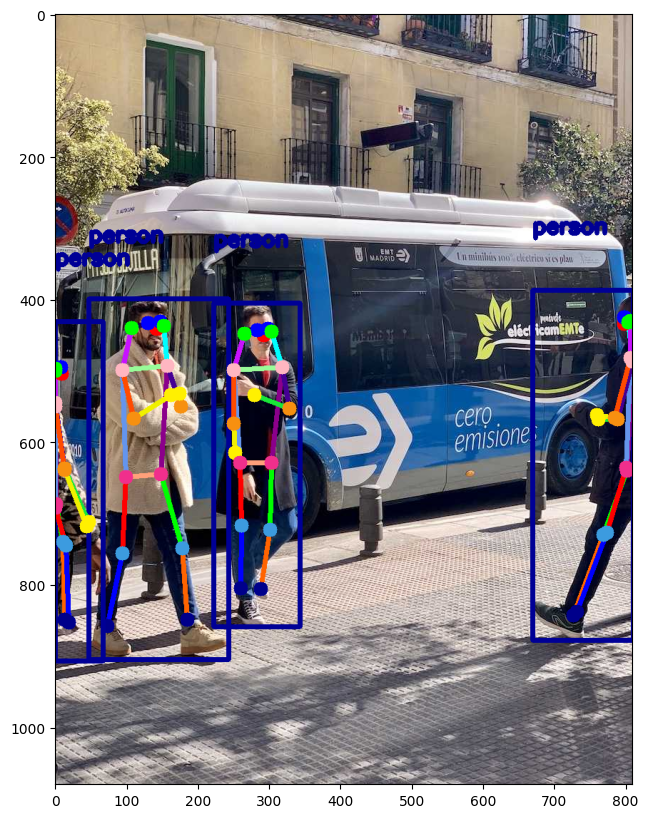

In [13]:
image=imread(os.path.join(output_dirpath, 'bus.jpg')) # BGR HxWxC
plt.figure(figsize=(10,10))
skeletons_overlay(img_bgr=image, results=results[0], output_filename=os.path.join(output_dirpath, 'bus_output.jpg'))
skeletons_overlay(img_bgr=image, results=results[0])